# Análise com Pandas

In [40]:
LIMITE_SUSPEITO = 10000.00
CSV_PATH = '/content/transacoes.csv'
JSON_PATH = '/content/relatorio.json'

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="white", context="talk")

dados = pd.read_csv(CSV_PATH)


### Limpeza e Validação de Dados



In [41]:
def limpar_dados(dados):
  dados_limpos = dados.copy()

  # 1. Validar 'id': deve ser numérico e não nulo
  dados_limpos['id_numerico'] = pd.to_numeric(dados_limpos['id'], errors='coerce')
  condicao_id = dados_limpos['id_numerico'].notna()

  # 2. Validar 'cliente_id': não deve ser nulo
  condicao_cliente_id = dados_limpos['cliente_id'].notna()

  # 3. Validar 'data': formato AAAA-MM-DD e converter para datetime
  dados_limpos['data_dt'] = pd.to_datetime(dados_limpos['data'], errors='coerce', format='%Y-%m-%d')
  condicao_data = dados_limpos['data_dt'].notna()

  # 4. Validar 'tipo': deve ser 'credito' ou 'debito'
  condicao_tipo = dados_limpos['tipo'].isin(['credito', 'debito'])

  # 5. Validar 'valor': deve ser numérico e maior que zero
  dados_limpos['valor_numerico'] = pd.to_numeric(dados_limpos['valor'], errors='coerce')
  condicao_valor = (dados_limpos['valor_numerico'].notna()) & (dados_limpos['valor_numerico'] > 0)

  # Combinar todas as condições para identificar linhas válidas
  condicoes_validas = condicao_id & condicao_cliente_id & condicao_data & condicao_tipo & condicao_valor

  # Filtrar o DataFrame para manter apenas linhas válidas
  dados_validos = dados_limpos[condicoes_validas].copy()

  # Converter colunas para os tipos finais desejados após a filtragem
  dados_validos['id'] = dados_validos['id_numerico'].astype(int)
  dados_validos['data'] = dados_validos['data_dt']
  dados_validos['valor'] = dados_validos['valor_numerico'].astype(float)

  # Criar a coluna 'mes_ref' (AAAA-MM)
  dados_validos['mes_ref'] = dados_validos['data'].dt.strftime('%Y-%m')

  # Manter apenas as colunas originais mais 'mes_ref'
  colunas_finais = [
      'id', 'cliente_id', 'data', 'tipo', 'valor', 'descricao', 'categoria', 'mes_ref'
  ]

  return dados_validos[colunas_finais]


dados_validos = limpar_dados(dados)
print(f"Total de linhas antes da limpeza: {len(dados)}")
print(f"Total de linhas válidas após a limpeza: {len(dados_validos)}")


Total de linhas antes da limpeza: 100
Total de linhas válidas após a limpeza: 90


## Agrupamento e cálculos


In [42]:
# Calcular o saldo mensal (crédito - débito)
def saldo_mensal():
  saldo_mensal = dados_validos.copy()
  saldo_mensal['valor_ajustado'] = np.where(saldo_mensal['tipo'] == 'credito', saldo_mensal['valor'], -saldo_mensal['valor'])
  return saldo_mensal.groupby('mes_ref')['valor_ajustado'].sum().reset_index()

# Transações do tipo débito
def dados_debito():
  return dados_validos[dados_validos['tipo'] == 'debito']

# Resumo mensal
def resumo_mensal():
  return dados_validos.groupby('mes_ref').agg(
      quantidade=('id', 'count'),
      total_credito=('valor', lambda x: x[dados_validos.loc[x.index, 'tipo'] == 'credito'].sum()),
      total_debito=('valor', lambda x: x[dados_validos.loc[x.index, 'tipo'] == 'debito'].sum())
  ).reset_index()

## Comparação de dados com a versão nativa

In [43]:
import json
import numpy as np

def ler_relatorio_json():
  try:
      with open(JSON_PATH, 'r', encoding='utf-8') as f:
          resultado_nativo = json.load(f)
      print("Relatório nativo carregado com sucesso para comparação.")
      return resultado_nativo['resumo_mensal']


  except FileNotFoundError:
      print("Erro: 'relatorio.json' não encontrado. Execute o notebook 'desafio-final.ipynb' antes deste, para gerar o arquivo.")
      return None

  except json.JSONDecodeError as e:
      print(f"Erro: 'relatorio.json' encontrado, mas o conteúdo está corrompido ou mal formatado: {e}")
      return None

  except KeyError:
      print("Erro: 'relatorio.json' não contém a chave 'resumo_mensal' esperada. Verifique se o arquivo foi gerado pela versão mais recente do notebook nativo.")
      return None
  except Exception as e:
      print(f"Erro inesperado ao carregar 'relatorio.json': {e}")
      return None

def compara_dados():
  resumo_nativo = ler_relatorio_json()
  if resumo_nativo is None:
    print("Comparação não realizada — dados nativos indisponíveis.")
    return

  print()
  print("========= COMPARAÇÃO DE DADOS COM A VERSÃO NATIVA ==========")
  print()
  print("-" * 60)
  print(f"{'Mês':<10}{'Métrica':<15}{'Nativo':>12}{'Pandas':>12}  Status")
  print("-" * 60)

  divergencias = 0
  resumo_mensal_pandas = resumo_mensal().set_index('mes_ref').to_dict(orient='index')
  for mes, dados_nativo in sorted(resumo_nativo.items()):
      if mes not in resumo_mensal_pandas:
          print(f"Aviso: Mês {mes} encontrado no relatório nativo, mas não nos dados do Pandas.")
          continue

      dados_pandas = resumo_mensal_pandas[mes]
      for chave in ['quantidade', 'total_credito', 'total_debito']:
          valor_nativo = round(dados_nativo[chave], 2)
          valor_pandas = round(dados_pandas.get(chave, 0),2)
          ok = valor_nativo == valor_pandas

          if not ok:
              divergencias += 1
          print(f"{mes:<10}{chave:<15}{valor_nativo:>12}{valor_pandas:>12}  {'  ✅' if ok else '  ❌'}")

  print(f"\n{'Todos os valores conferem!' if divergencias == 0 else f'{divergencias} divergência(s) encontrada(s)!'}")

compara_dados()

Relatório nativo carregado com sucesso para comparação.

========= COMPARAÇÃO DE DADOS COM A VERSÃO NATIVA ==========

------------------------------------------------------------
Mês       Métrica              Nativo      Pandas  Status
------------------------------------------------------------
2026-01   quantidade               25          25    ✅
2026-01   total_credito      61320.06    61320.06    ✅
2026-01   total_debito       11042.75    11042.75    ✅
2026-02   quantidade               27          27    ✅
2026-02   total_credito      73556.49    73556.49    ✅
2026-02   total_debito        8521.37     8521.37    ✅
2026-03   quantidade               25          25    ✅
2026-03   total_credito      41487.63    41487.63    ✅
2026-03   total_debito       11903.89    11903.89    ✅
2026-04   quantidade               13          13    ✅
2026-04   total_credito       38742.4     38742.4    ✅
2026-04   total_debito        4399.34     4399.34    ✅

Todos os valores conferem!


## Gráfico de barras
Saldo mensal (crédito - débito por mês)

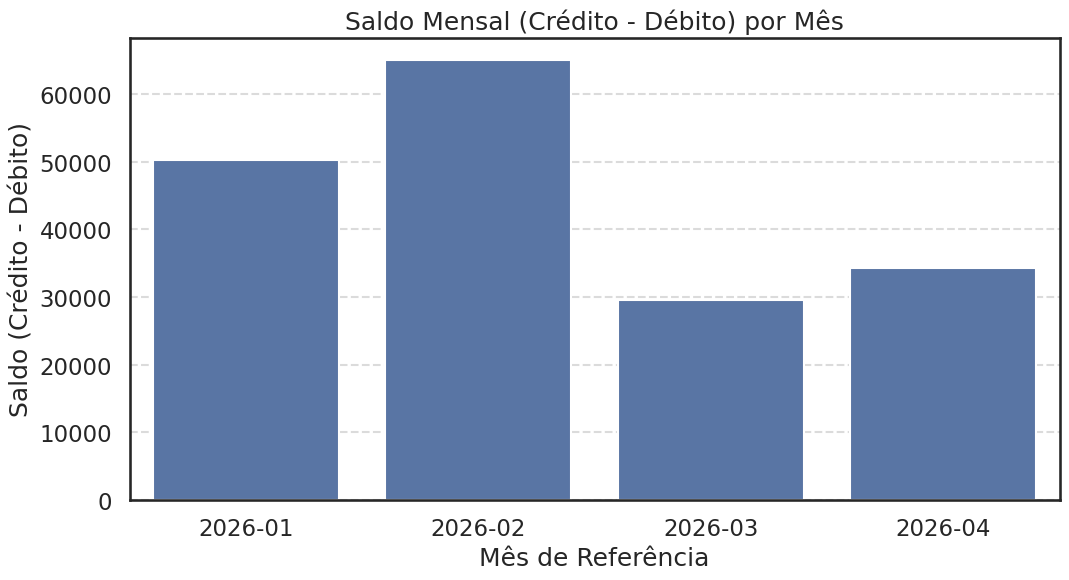

In [44]:
plt.figure(figsize=(12, 6))
sns.barplot(x='mes_ref', y='valor_ajustado', data=saldo_mensal())
plt.title('Saldo Mensal (Crédito - Débito) por Mês')
plt.xlabel('Mês de Referência')
plt.ylabel('Saldo (Crédito - Débito)')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Gráfico de linha com evolução do total de débito ao longo dos meses

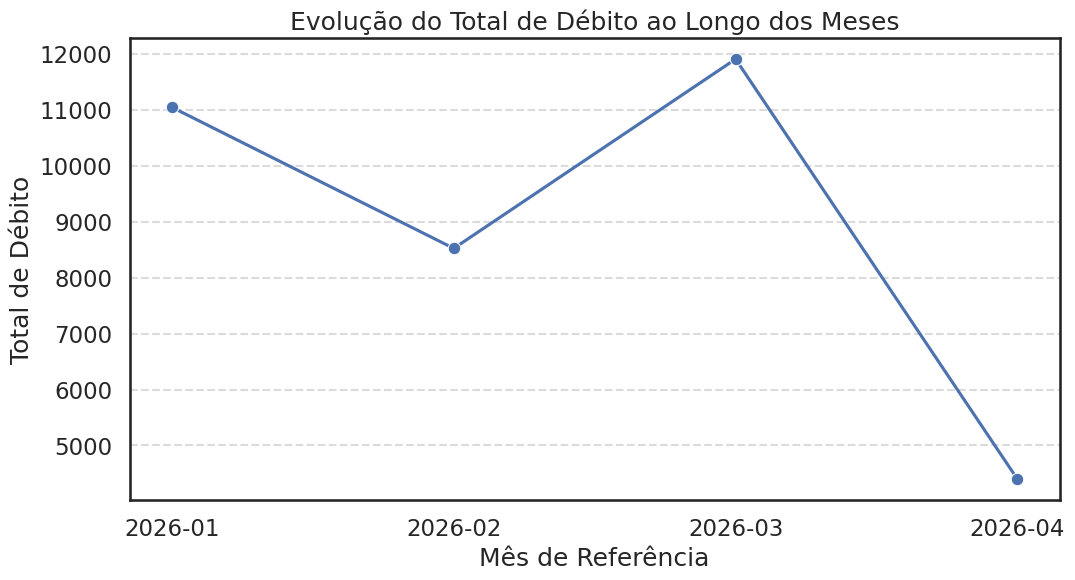

In [45]:
# Calcular o total de débito por mês
total_debito_por_mes = dados_debito().groupby('mes_ref')['valor'].sum().reset_index()

plt.figure(figsize=(12, 6))
sns.lineplot(x='mes_ref', y='valor', data=total_debito_por_mes, marker='o')
plt.title('Evolução do Total de Débito ao Longo dos Meses')
plt.xlabel('Mês de Referência')
plt.ylabel('Total de Débito')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

## Gráfico de barras empilhadas com crédido e débito por mês


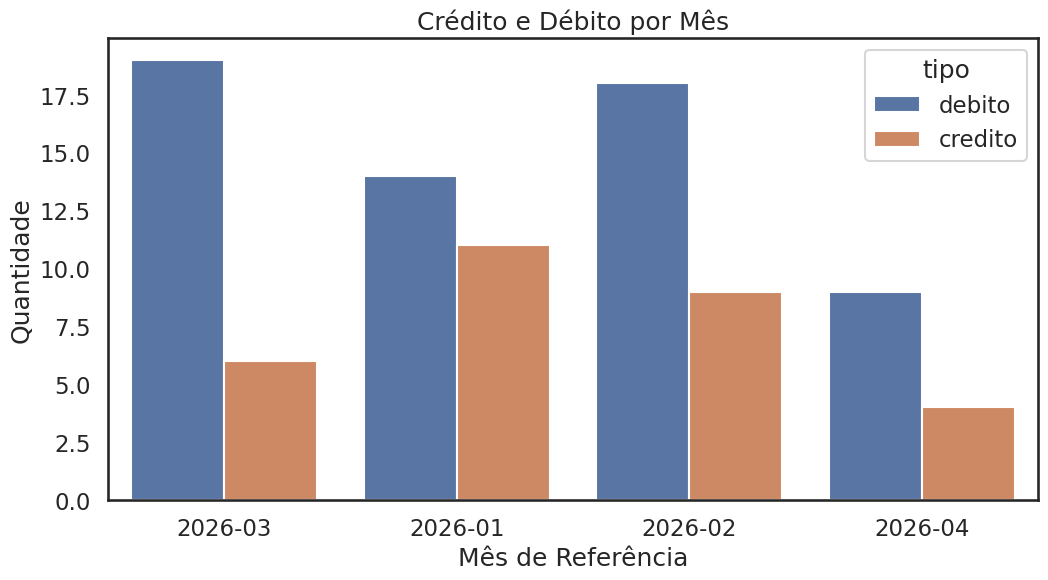

In [46]:
plt.figure(figsize=(12, 6))
sns.countplot(x='mes_ref', hue='tipo', data=dados_validos)
plt.title('Crédito e Débito por Mês')
plt.xlabel('Mês de Referência')
plt.ylabel('Quantidade')
plt.show()

# Todos os gráficos na imagem

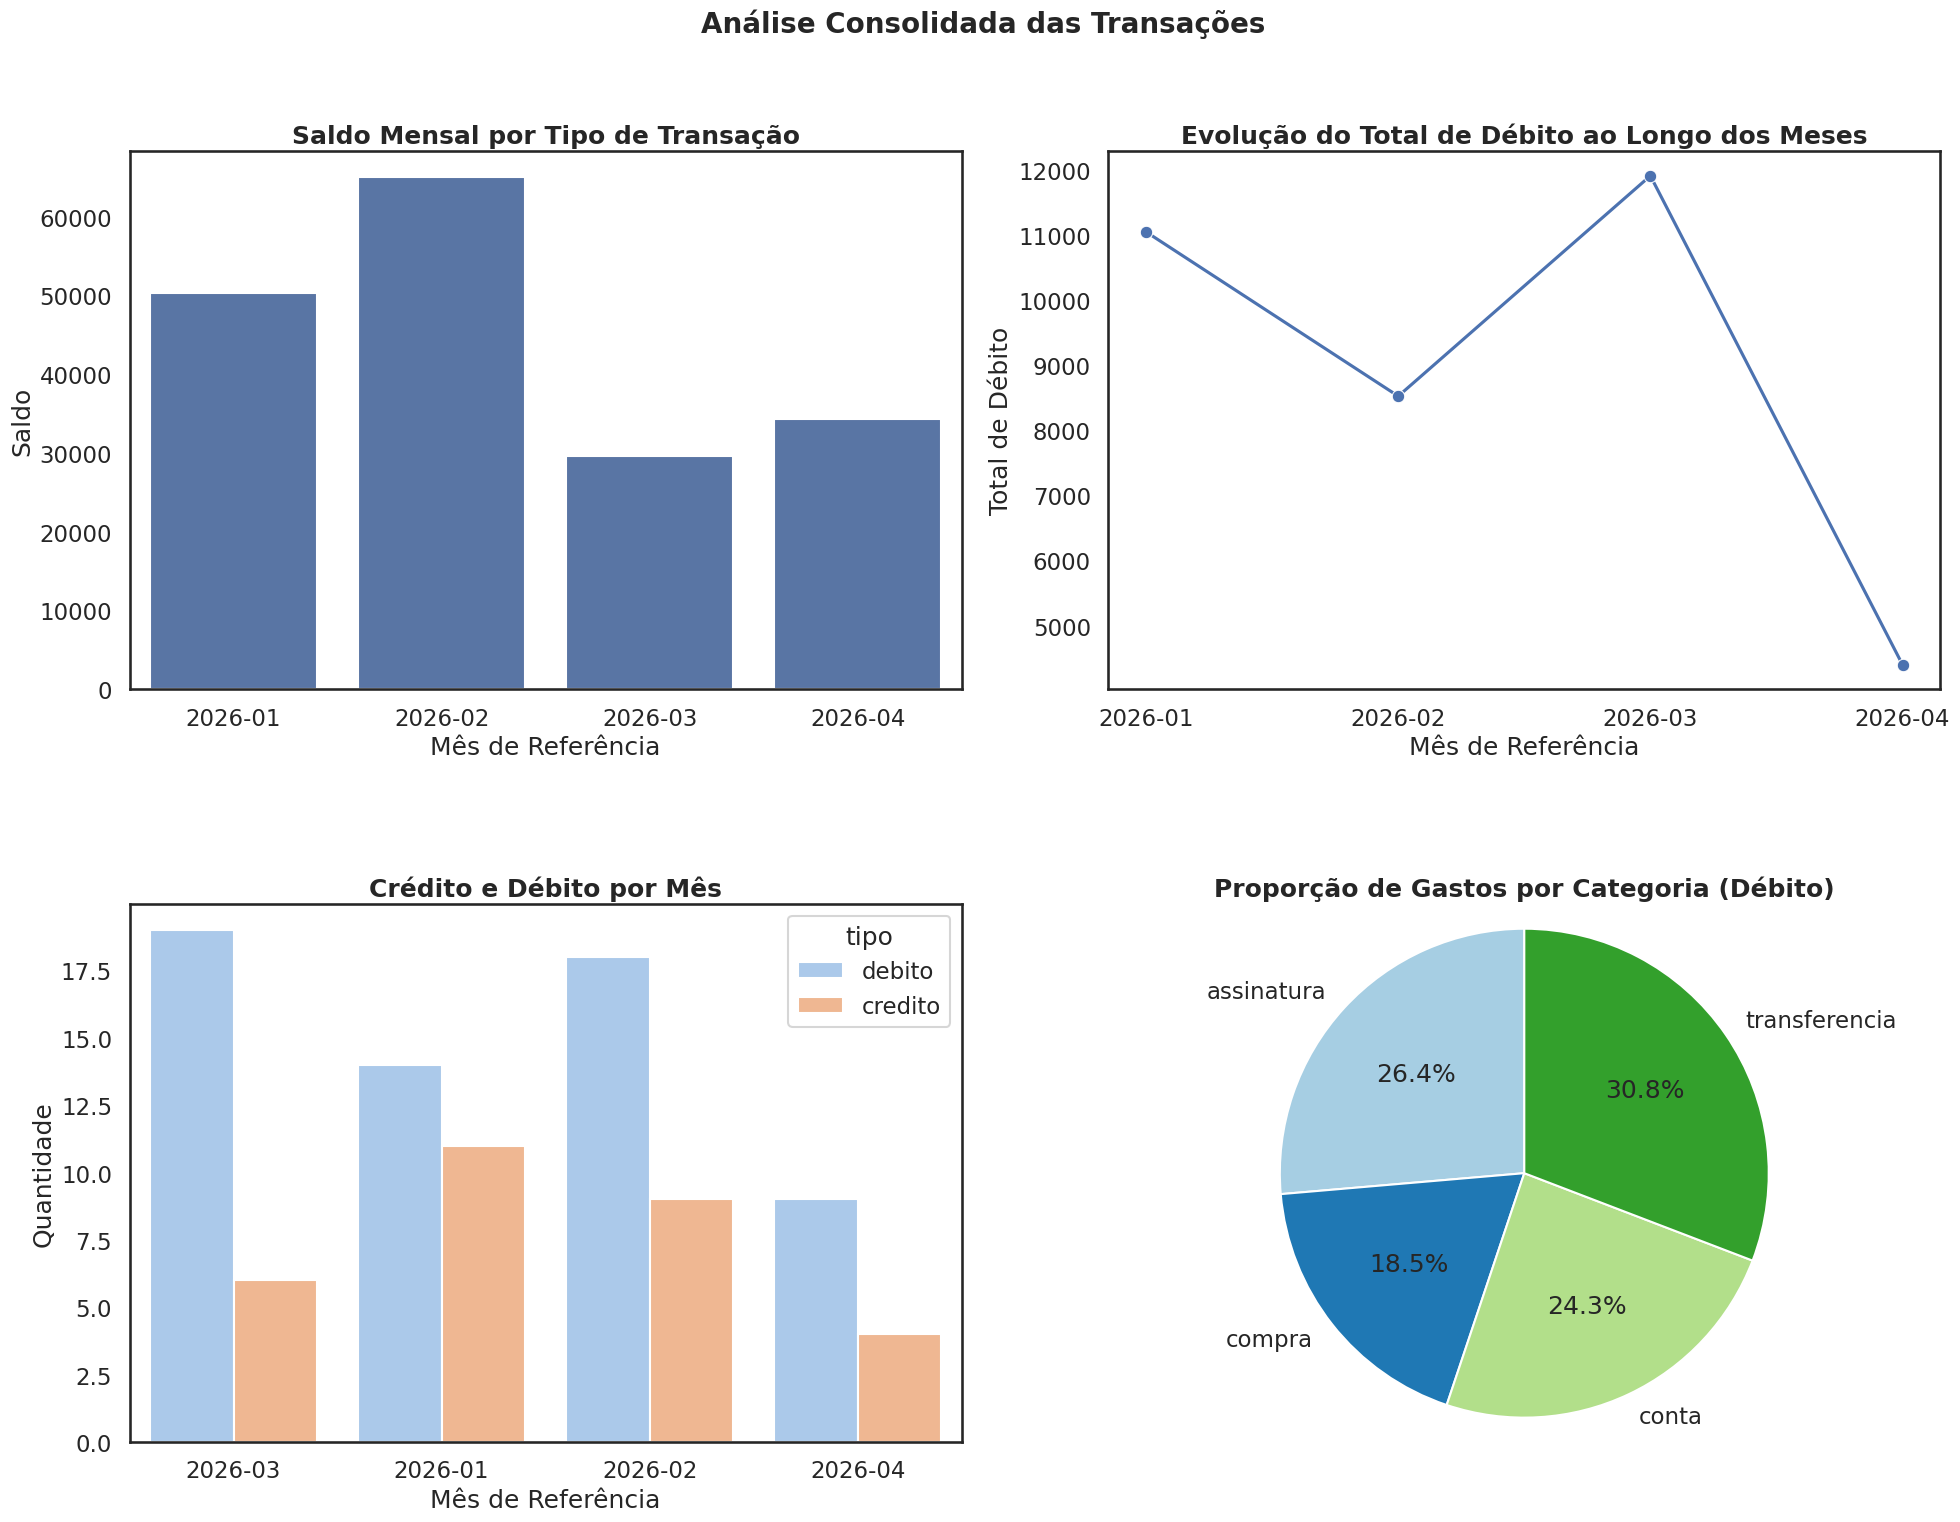

In [47]:


fig, axes = plt.subplots(2, 2, figsize=(20, 15))
fig.suptitle('Análise Consolidada das Transações', fontsize=20, y=1.02, fontweight='bold')

# Gráfico 1: Saldo Mensal por Tipo de Transação
sns.barplot(x='mes_ref', y='valor_ajustado', data=saldo_mensal(), ax=axes[0, 0])
axes[0, 0].set_title('Saldo Mensal por Tipo de Transação', fontweight='bold')
axes[0, 0].set_xlabel('Mês de Referência')
axes[0, 0].set_ylabel('Saldo')

# Gráfico 2: Evolução do Total de Débito ao Longo dos Meses
total_debito_por_mes = dados_debito().groupby('mes_ref')['valor'].sum().reset_index()
sns.lineplot(x='mes_ref', y='valor', data=total_debito_por_mes, ax=axes[0, 1], marker='o')
axes[0, 1].set_title('Evolução do Total de Débito ao Longo dos Meses', fontweight='bold')
axes[0, 1].set_xlabel('Mês de Referência')
axes[0, 1].set_ylabel('Total de Débito')


# Gráfico 3: Crédito e Débito por Mês
sns.countplot(x='mes_ref', hue='tipo', data=dados_validos, ax=axes[1, 0], palette='pastel')
axes[1, 0].set_title('Crédito e Débito por Mês', fontweight='bold')
axes[1, 0].set_xlabel('Mês de Referência')
axes[1, 0].set_ylabel('Quantidade')

# Gráfico 4: Proporção de Gastos por Categoria (Débito)
gastos_por_categoria = dados_debito().groupby('categoria')['valor'].sum()
axes[1, 1].pie(gastos_por_categoria, labels=gastos_por_categoria.index, autopct='%1.1f%%', startangle=90, colors=plt.cm.Paired.colors)
axes[1, 1].set_title('Proporção de Gastos por Categoria (Débito)', fontweight='bold')
axes[1, 1].set_ylabel('')
axes[1, 1].axis('equal')

plt.tight_layout()
fig.subplots_adjust(hspace=0.4)
plt.show()